# Лабораторная работа №6
Поток: РНИФ (3к_Нейротех) 1.1
Поток: РНИФ (3к_Нейротех) 1.1

Выполнили:

Егорова Варвара 408575

Ташкинова Татьяна 413084

Аббясов Радислам 367038

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.signal import savgol_filter

FILES_CONFIG = {

    "breathe_KGR.dat": {
        "intervals": [0, 100, 120, 170, 200, 230, 300],
        "labels": [
            "Фон",
            "Испытание 1",
            "Испытание 2",
            "Испытание 3",
            "Испытание 4",
            "Испытание 5"
        ]
    },

    "count_KGR.dat": {
        "intervals": [0, 50, 100, 180, 240, 280, 330],
        "labels": [
            "Фон",
            "Испытание 1",
            "Испытание 2",
            "Испытание 3",
            "Испытание 4",
            "Испытание 5"
        ]
    },

    "fingers_KGR.dat": {
        "intervals": [0, 50, 100, 150, 200, 250, 300],
        "labels": [
            "Фон",
            "Испытание 1",
            "Испытание 2",
            "Испытание 3",
            "Испытание 4",
            "Испытание 5"
        ]
    },

    "scare_KGR.dat": {
        "intervals": [0, 80, 110, 150, 200, 250, 300],
        "labels": [
            "Фон",
            "Испытание 1",
            "Испытание 2",
            "Испытание 3",
            "Испытание 4",
            "Испытание 5"
        ]
    }
}


## Загрузка данных

In [ ]:

def load_signal(filepath):

    print(f"\n Загружаем файл {filepath} \n")

    df = pd.read_csv(
        filepath,
        sep=r"\s+|,|;",
        engine="python",
        header=None
    )

    df = df.iloc[:, :2]

    df.columns = [
        "t",
        "conductance_uS"
    ]

    df = df.dropna()

    df["t"] = pd.to_numeric(
        df["t"],
        errors="coerce"
    )

    df["conductance_uS"] = pd.to_numeric(
        df["conductance_uS"],
        errors="coerce"
    )

    df = df.dropna()

    df["t"] = (
        df["t"] - df["t"].iloc[0]
    )

    return df



## Удаление выбросов

Сначала убирем дубликаты по времени и выбросы с помощью стандартного z-score. Проведем сглаживание с помощью фильтра Савицкого-Голея (он лучше сохраняет форму оригинального сигнала).



In [ ]:
def remove_outliers_iqr(df):
    print("\n Удаляем выбросы... \n ")

    q1 = df["conductance_uS"].quantile(0.25)

    q3 = df["conductance_uS"].quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    print(f"\nQ1: {q1:.4f}")
    print(f"Q3: {q3:.4f}")
    print(f"IQR: {iqr:.4f}")

    print(f"\nНижняя граница: {lower:.4f}")
    print(f"Верхняя граница: {upper:.4f}")

    df_clean = df[
        (df["conductance_uS"] >= lower) &
        (df["conductance_uS"] <= upper)
    ]

    removed = len(df) - len(df_clean)

    print(f"\nУдалено выбросов: {removed}")

    return df_clean



Сглаживание с помощью аппроксимации

In [ ]:
def smooth_signal(df):
    print("\nСглаживаем сигнал... \n ")

    signal = df["conductance_uS"].values

    window = 101

    if window >= len(signal):
        window = len(signal) - 1

    if window % 2 == 0:
        window -= 1

    smooth = savgol_filter(
        signal,
        window_length=window,
        polyorder=3
    )

    df["smoothed"] = smooth

    return df



## Разделение на интервалы




In [ ]:
def split_intervals(df, intervals, labels):
    print("\n Разделяем на интервалы \n")
    print("Каждый интервал - отдельное испытание\n")

    segments = []

    for i in range(len(intervals) - 1):

        start = intervals[i]
        end = intervals[i + 1]

        segment = df[
            (df["t"] >= start) &
            (df["t"] < end)
        ]

        segments.append(segment)

        print(
            f"{labels[i]}: "
            f"{start} - {end} сек"
        )

    return segments


Графики файла

In [ ]:
def plot_signal(df, segments, labels, title):

    fig, axes = plt.subplots(
        3,
        1,
        figsize=(16, 16)
    )

    axes[0].plot(
        df["t"],
        df["conductance_uS"],
        linewidth=1.2,
        label="Исходный сигнал"
    )

    axes[0].set_title(
        f"{title} — исходный сигнал"
    )

    axes[0].set_xlabel("Время, сек")
    axes[0].set_ylabel("КГР")

    axes[0].grid(True)
    axes[0].legend()


    axes[1].plot(
        df["t"],
        df["conductance_uS"],
        linewidth=1.2,
        label="После удаления выбросов"
    )

    axes[1].set_title(
        f"{title} — после IQR"
    )

    axes[1].set_xlabel("Время, сек")
    axes[1].set_ylabel("КГР")

    axes[1].grid(True)
    axes[1].legend()

    axes[2].plot(
        df["t"],
        df["smoothed"],
        linewidth=2,
        label="Аппроксмация"
    )

    for seg in segments:

        axes[2].axvline(
            seg["t"].iloc[0],
            linestyle="--",
            alpha=0.7
        )

    for i, seg in enumerate(segments):

        middle = (
            seg["t"].iloc[0] +
            seg["t"].iloc[-1]
        ) / 2

        axes[2].text(
            middle,
            df["smoothed"].max() * 0.95,
            labels[i],
            ha="center",
            fontsize=10,
            bbox=dict(
                facecolor="white",
                alpha=0.7,
                edgecolor="gray"
            )
        )

    axes[2].set_title(
        f"{title} Аппроксимация"
    )

    axes[2].set_xlabel("Время, сек")
    axes[2].set_ylabel("Проводимость")

    axes[2].grid(True)
    axes[2].legend()

    plt.tight_layout()
    plt.show()



In [ ]:
def analyze_peaks(segments, labels, filename):
    print("\nАнализ проводимости \n")

    results = []

    # пропускаем фон
    analyzed_segments = segments[1:]
    analyzed_labels = labels[1:]

    plt.figure(figsize=(16, 10))

    for i, segment in enumerate(analyzed_segments):

        label = analyzed_labels[i]

        signal = segment["smoothed"].values
        time = segment["t"].values

        max_idx = np.argmax(signal)
        min_idx = np.argmin(signal)

        max_value = signal[max_idx]
        min_value = signal[min_idx]

        max_time = time[max_idx]
        min_time = time[min_idx]

        delta = max_value - min_value

        print("\n")
        print("-" * 70)
        print(label)
        print("-" * 70)

        print(f"Минимальное значение: {min_value:.4f}")
        print(f"Максимальное значение: {max_value:.4f}")
        print(f"Изменение сигнала: {delta:.4f}")

        results.append({
            "interval": label,
            "min_signal": min_value,
            "max_signal": max_value,
            "delta_signal": delta,
            "min_time": min_time,
            "max_time": max_time
        })

        plt.subplot(5, 1, i + 1)

        plt.plot(
            time,
            signal,
            linewidth=2
        )

        plt.scatter(
            min_time,
            min_value,
            s=60,
            label="Минимум"
        )

        plt.scatter(
            max_time,
            max_value,
            s=60,
            label="Максимум"
        )

        plt.title(
            f"{filename} | {label}"
        )

        plt.ylabel("Проводимость")

        plt.grid(True)

        plt.legend()

    plt.xlabel("Время, сек")

    plt.tight_layout()

    plt.show()


    results_df = pd.DataFrame(results)

    print("\nИзменения\n")

    print(results_df)

    max_reaction_idx = results_df[
        "delta_signal"
    ].idxmax()

    max_reaction = results_df.iloc[
        max_reaction_idx
    ]

    print("\nАнализ\n")

    print(
        f"""
Наиболее выраженная реакция
наблюдается в интервале:

{max_reaction['interval']}

Максимальное изменение сигнала:
{max_reaction['delta_signal']:.4f}
"""
    )

    return results_df



## Запуск для каждого файла


Запуск для файла: breathe_KGR.dat 


 Загружаем файл breathe_KGR.dat 


 Удаляем выбросы... 
 

Q1: 1.2941
Q3: 2.2549
IQR: 0.9608

Нижняя граница: -0.1471
Верхняя граница: 3.6961

Удалено выбросов: 0

Сглаживаем сигнал... 
 

 Разделяем на интервалы 

Каждый интервал - отдельное испытание

Фон: 0 - 100 сек
Испытание 1: 100 - 120 сек
Испытание 2: 120 - 170 сек
Испытание 3: 170 - 200 сек
Испытание 4: 200 - 230 сек
Испытание 5: 230 - 300 сек


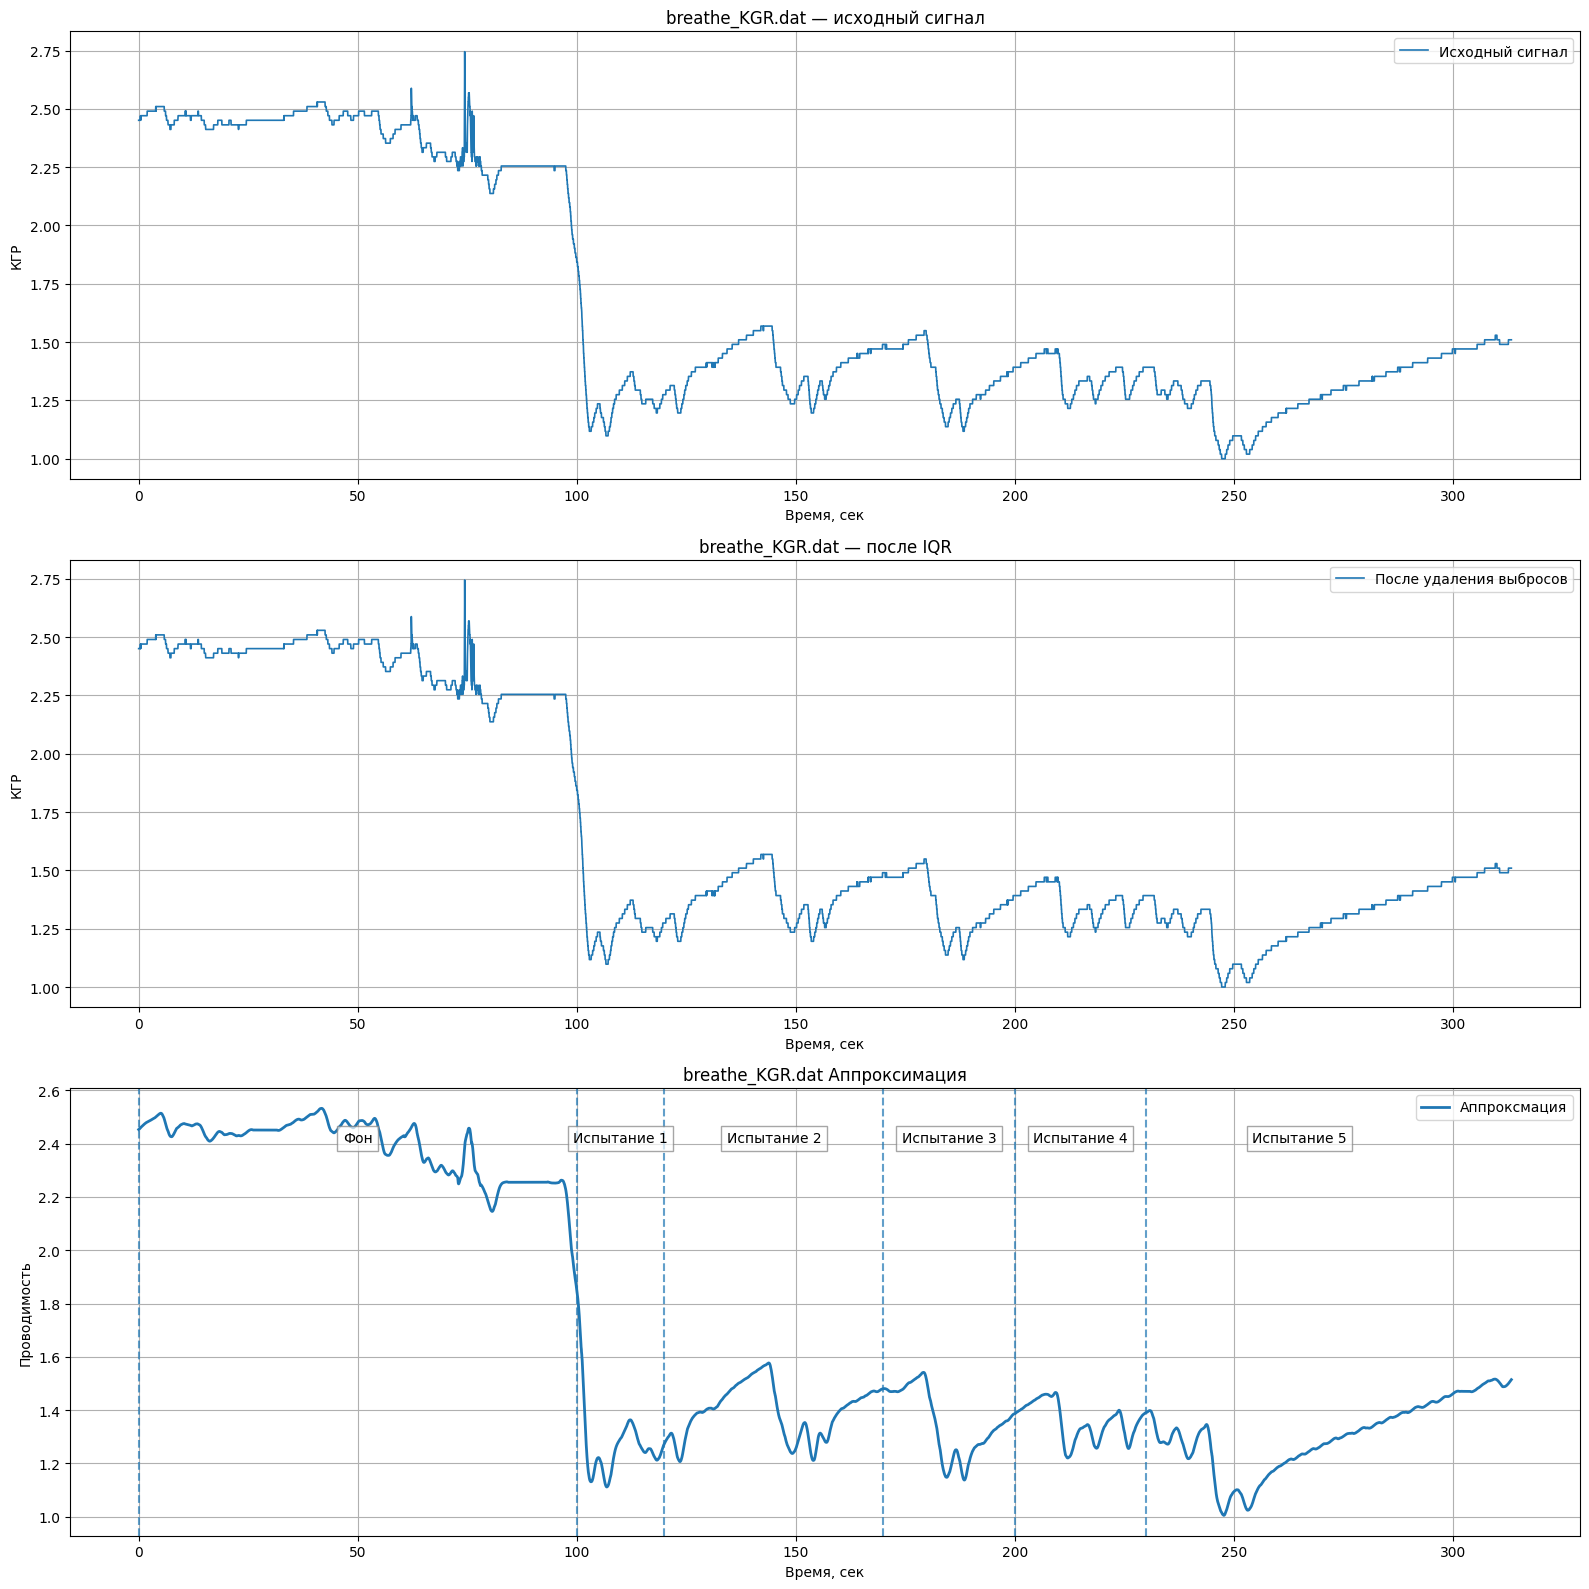


Анализ проводимости 



----------------------------------------------------------------------
Испытание 1
----------------------------------------------------------------------
Минимальное значение: 1.1118
Максимальное значение: 1.8520
Изменение сигнала: 0.7402


----------------------------------------------------------------------
Испытание 2
----------------------------------------------------------------------
Минимальное значение: 1.2069
Максимальное значение: 1.5772
Изменение сигнала: 0.3703


----------------------------------------------------------------------
Испытание 3
----------------------------------------------------------------------
Минимальное значение: 1.1377
Максимальное значение: 1.5418
Изменение сигнала: 0.4041


----------------------------------------------------------------------
Испытание 4
----------------------------------------------------------------------
Минимальное значение: 1.2204
Максимальное значение: 1.4665
Изменение сигнала: 0.2461


-----------

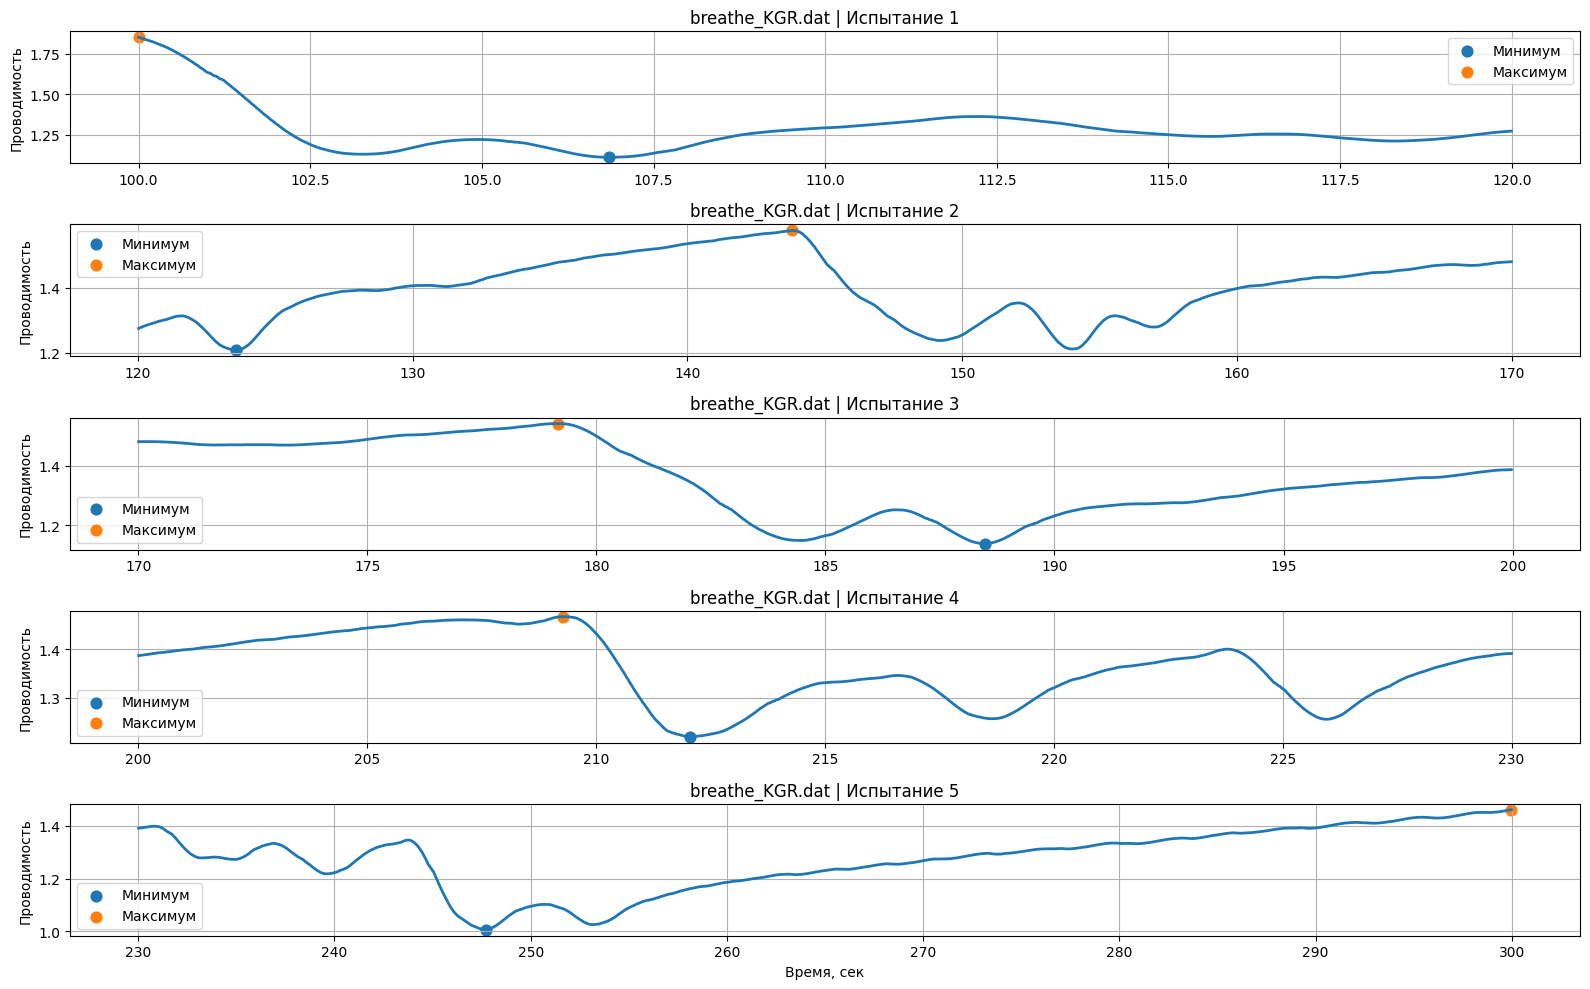


Изменения

      interval  min_signal  max_signal  delta_signal    min_time    max_time
0  Испытание 1    1.111776    1.852026      0.740250  106.845747  100.000509
1  Испытание 2    1.206880    1.577184      0.370304  123.566977  143.803091
2  Испытание 3    1.137741    1.541833      0.404093  188.473959  179.166998
3  Испытание 4    1.220404    1.466515      0.246112  212.040487  209.279455
4  Испытание 5    1.005278    1.461591      0.456313  247.707357  299.977224

Анализ


Наиболее выраженная реакция
наблюдается в интервале:

Испытание 1

Максимальное изменение сигнала:
0.7402


Запуск для файла: count_KGR.dat 


 Загружаем файл count_KGR.dat 


 Удаляем выбросы... 
 

Q1: 0.7255
Q3: 0.8824
IQR: 0.1569

Нижняя граница: 0.4902
Верхняя граница: 1.1176

Удалено выбросов: 348

Сглаживаем сигнал... 
 

 Разделяем на интервалы 

Каждый интервал - отдельное испытание

Фон: 0 - 50 сек
Испытание 1: 50 - 100 сек
Испытание 2: 100 - 180 сек
Испытание 3: 180 - 240 сек
Испытание 4: 240 - 280 с

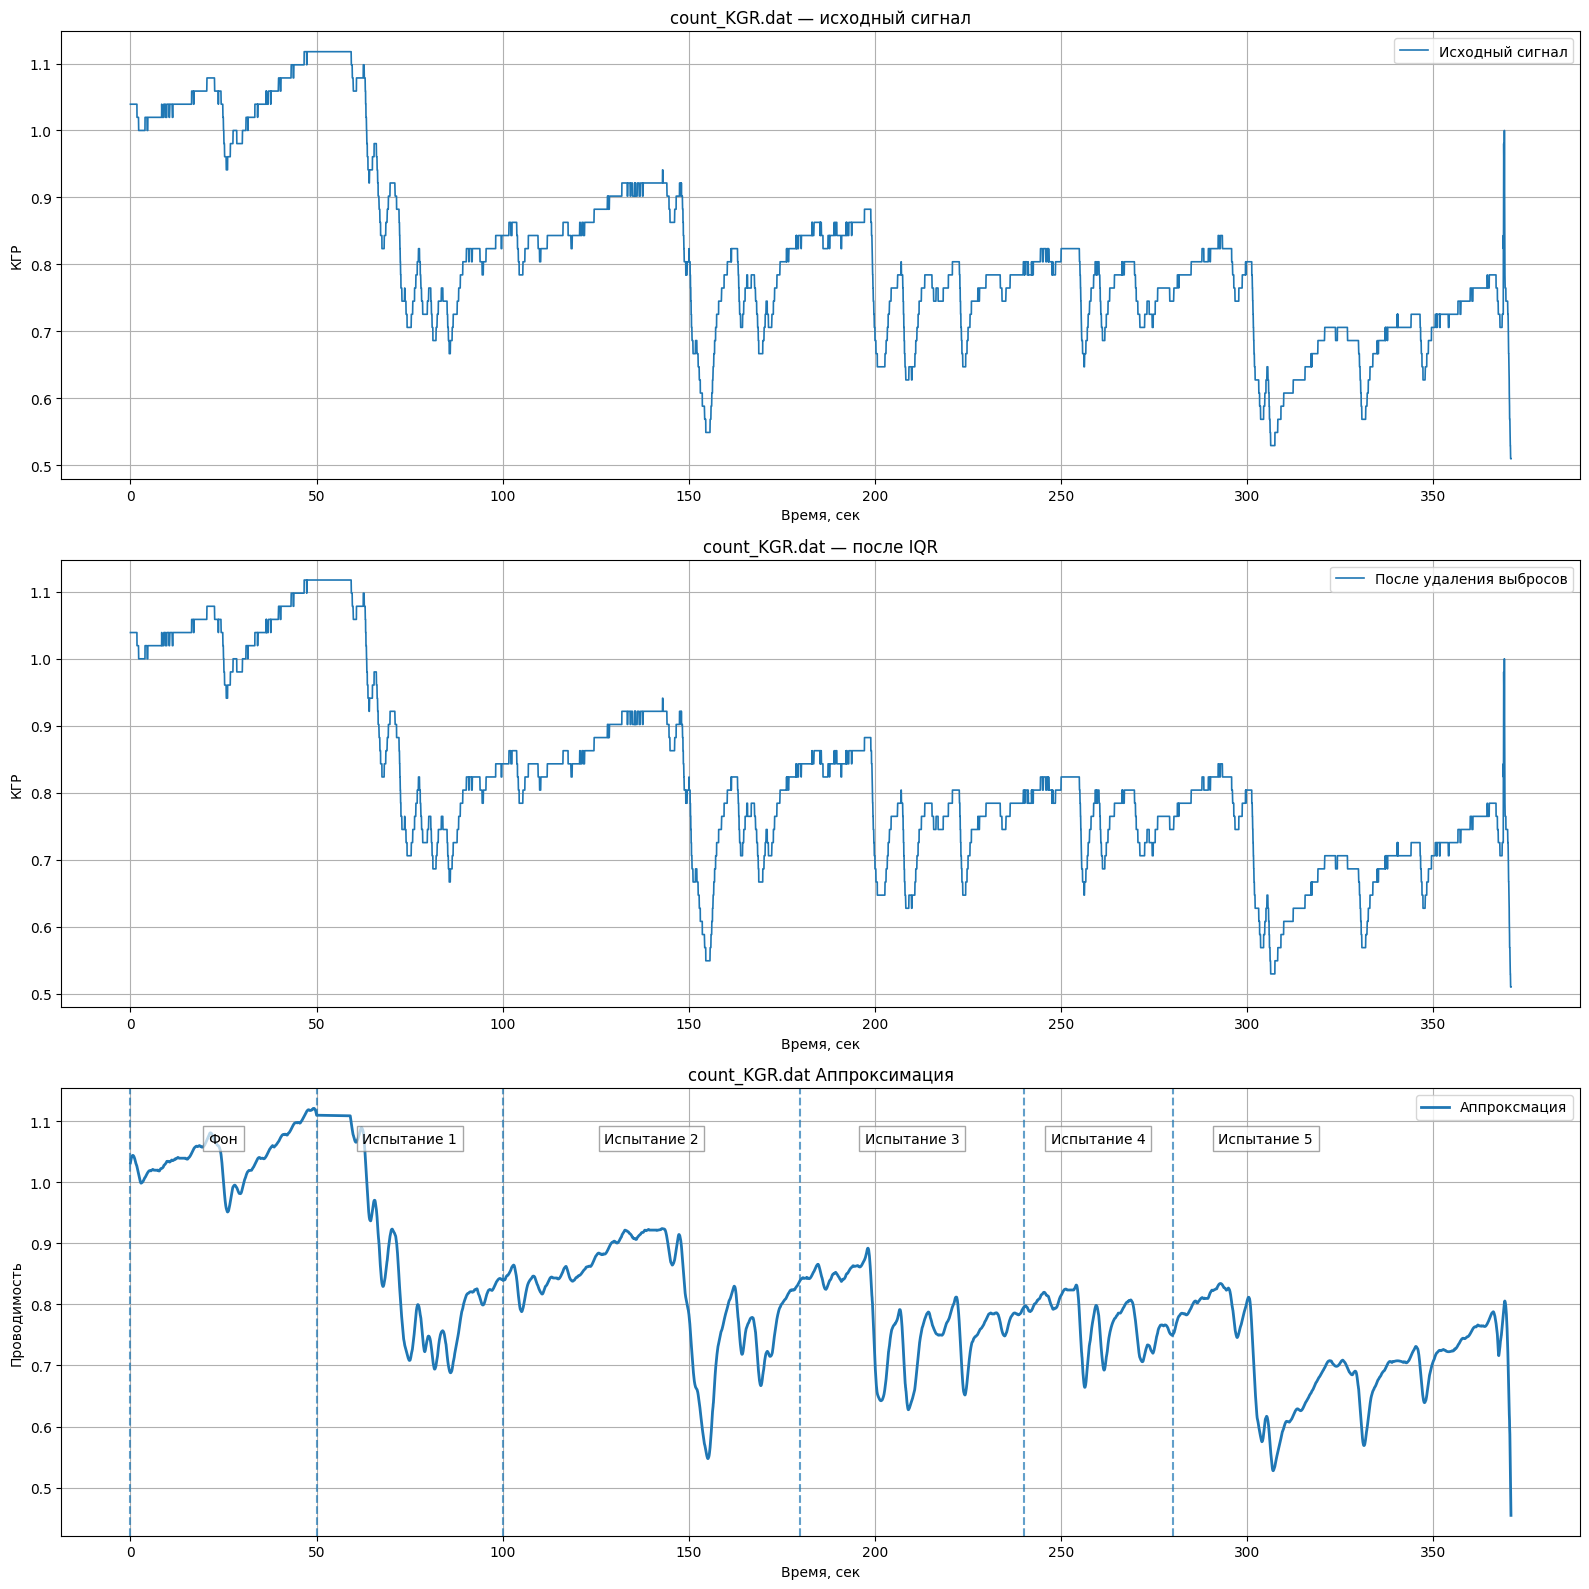


Анализ проводимости 



----------------------------------------------------------------------
Испытание 1
----------------------------------------------------------------------
Минимальное значение: 0.6880
Максимальное значение: 1.1096
Изменение сигнала: 0.4216


----------------------------------------------------------------------
Испытание 2
----------------------------------------------------------------------
Минимальное значение: 0.5474
Максимальное значение: 0.9240
Изменение сигнала: 0.3766


----------------------------------------------------------------------
Испытание 3
----------------------------------------------------------------------
Минимальное значение: 0.6275
Максимальное значение: 0.8920
Изменение сигнала: 0.2645


----------------------------------------------------------------------
Испытание 4
----------------------------------------------------------------------
Минимальное значение: 0.6641
Максимальное значение: 0.8316
Изменение сигнала: 0.1675


-----------

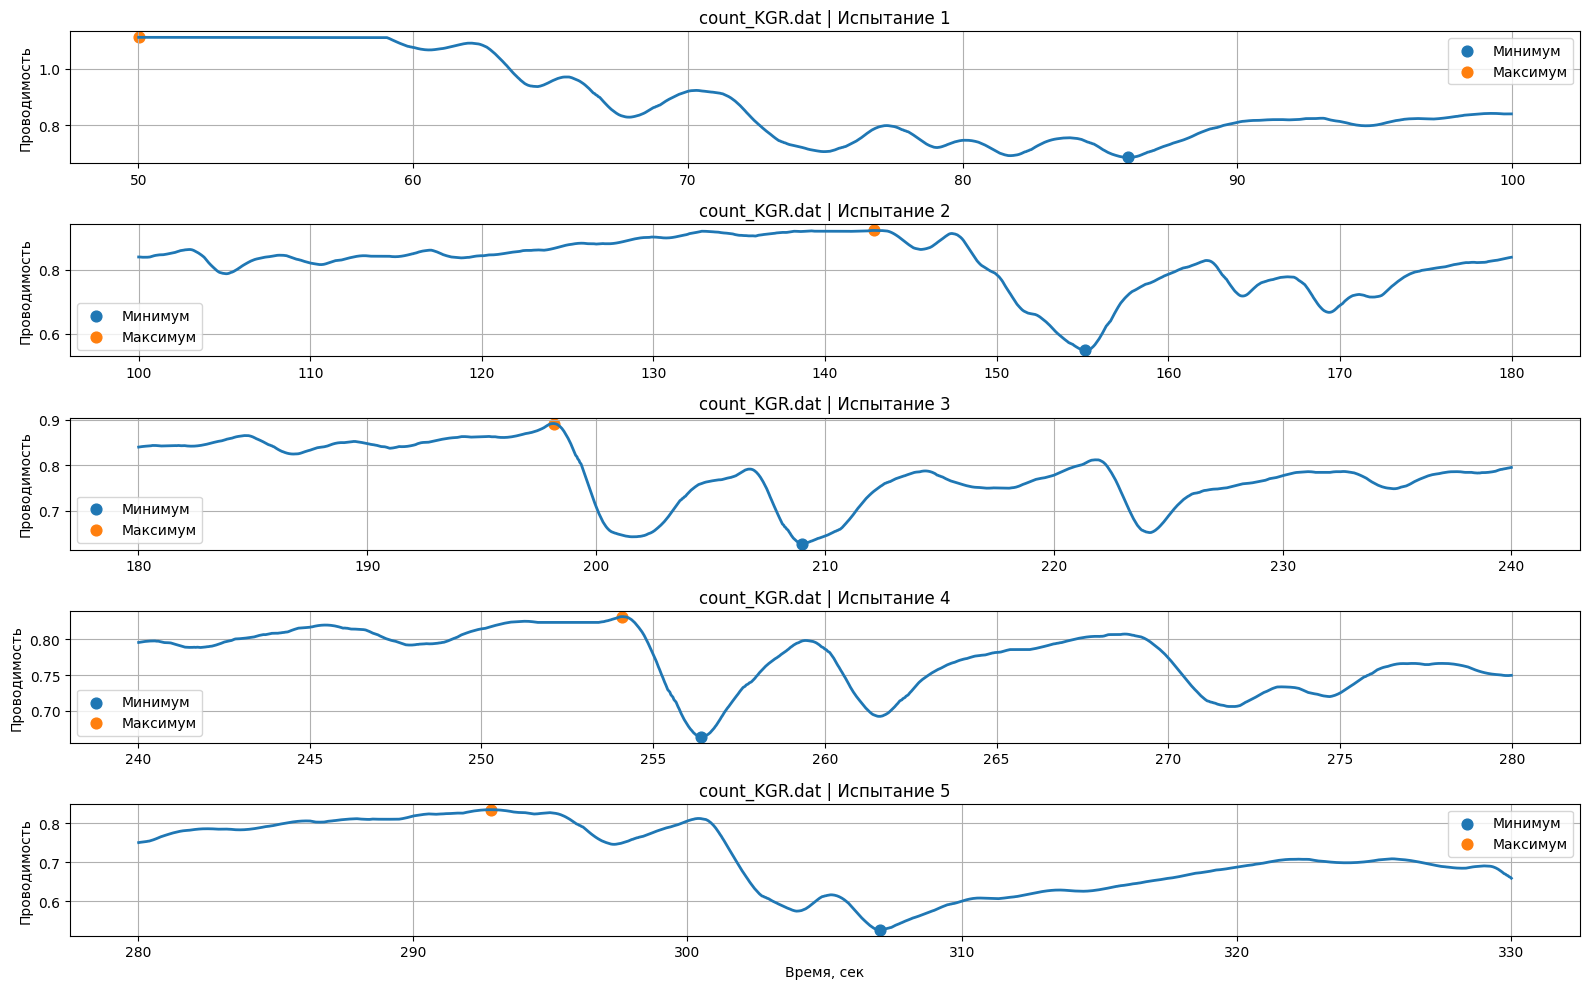


Изменения

      interval  min_signal  max_signal  delta_signal    min_time    max_time
0  Испытание 1    0.687970    1.109591      0.421621   86.011597   50.016724
1  Испытание 2    0.547428    0.924020      0.376592  155.154236  142.844604
2  Испытание 3    0.627474    0.891971      0.264497  209.013367  198.145630
3  Испытание 4    0.664106    0.831637      0.167531  256.387878  254.106201
4  Испытание 5    0.527670    0.834140      0.306470  307.002625  292.833313

Анализ


Наиболее выраженная реакция
наблюдается в интервале:

Испытание 1

Максимальное изменение сигнала:
0.4216


Запуск для файла: fingers_KGR.dat 


 Загружаем файл fingers_KGR.dat 


 Удаляем выбросы... 
 

Q1: 1.2353
Q3: 1.4706
IQR: 0.2353

Нижняя граница: 0.8824
Верхняя граница: 1.8235

Удалено выбросов: 0

Сглаживаем сигнал... 
 

 Разделяем на интервалы 

Каждый интервал - отдельное испытание

Фон: 0 - 50 сек
Испытание 1: 50 - 100 сек
Испытание 2: 100 - 150 сек
Испытание 3: 150 - 200 сек
Испытание 4: 200 - 250

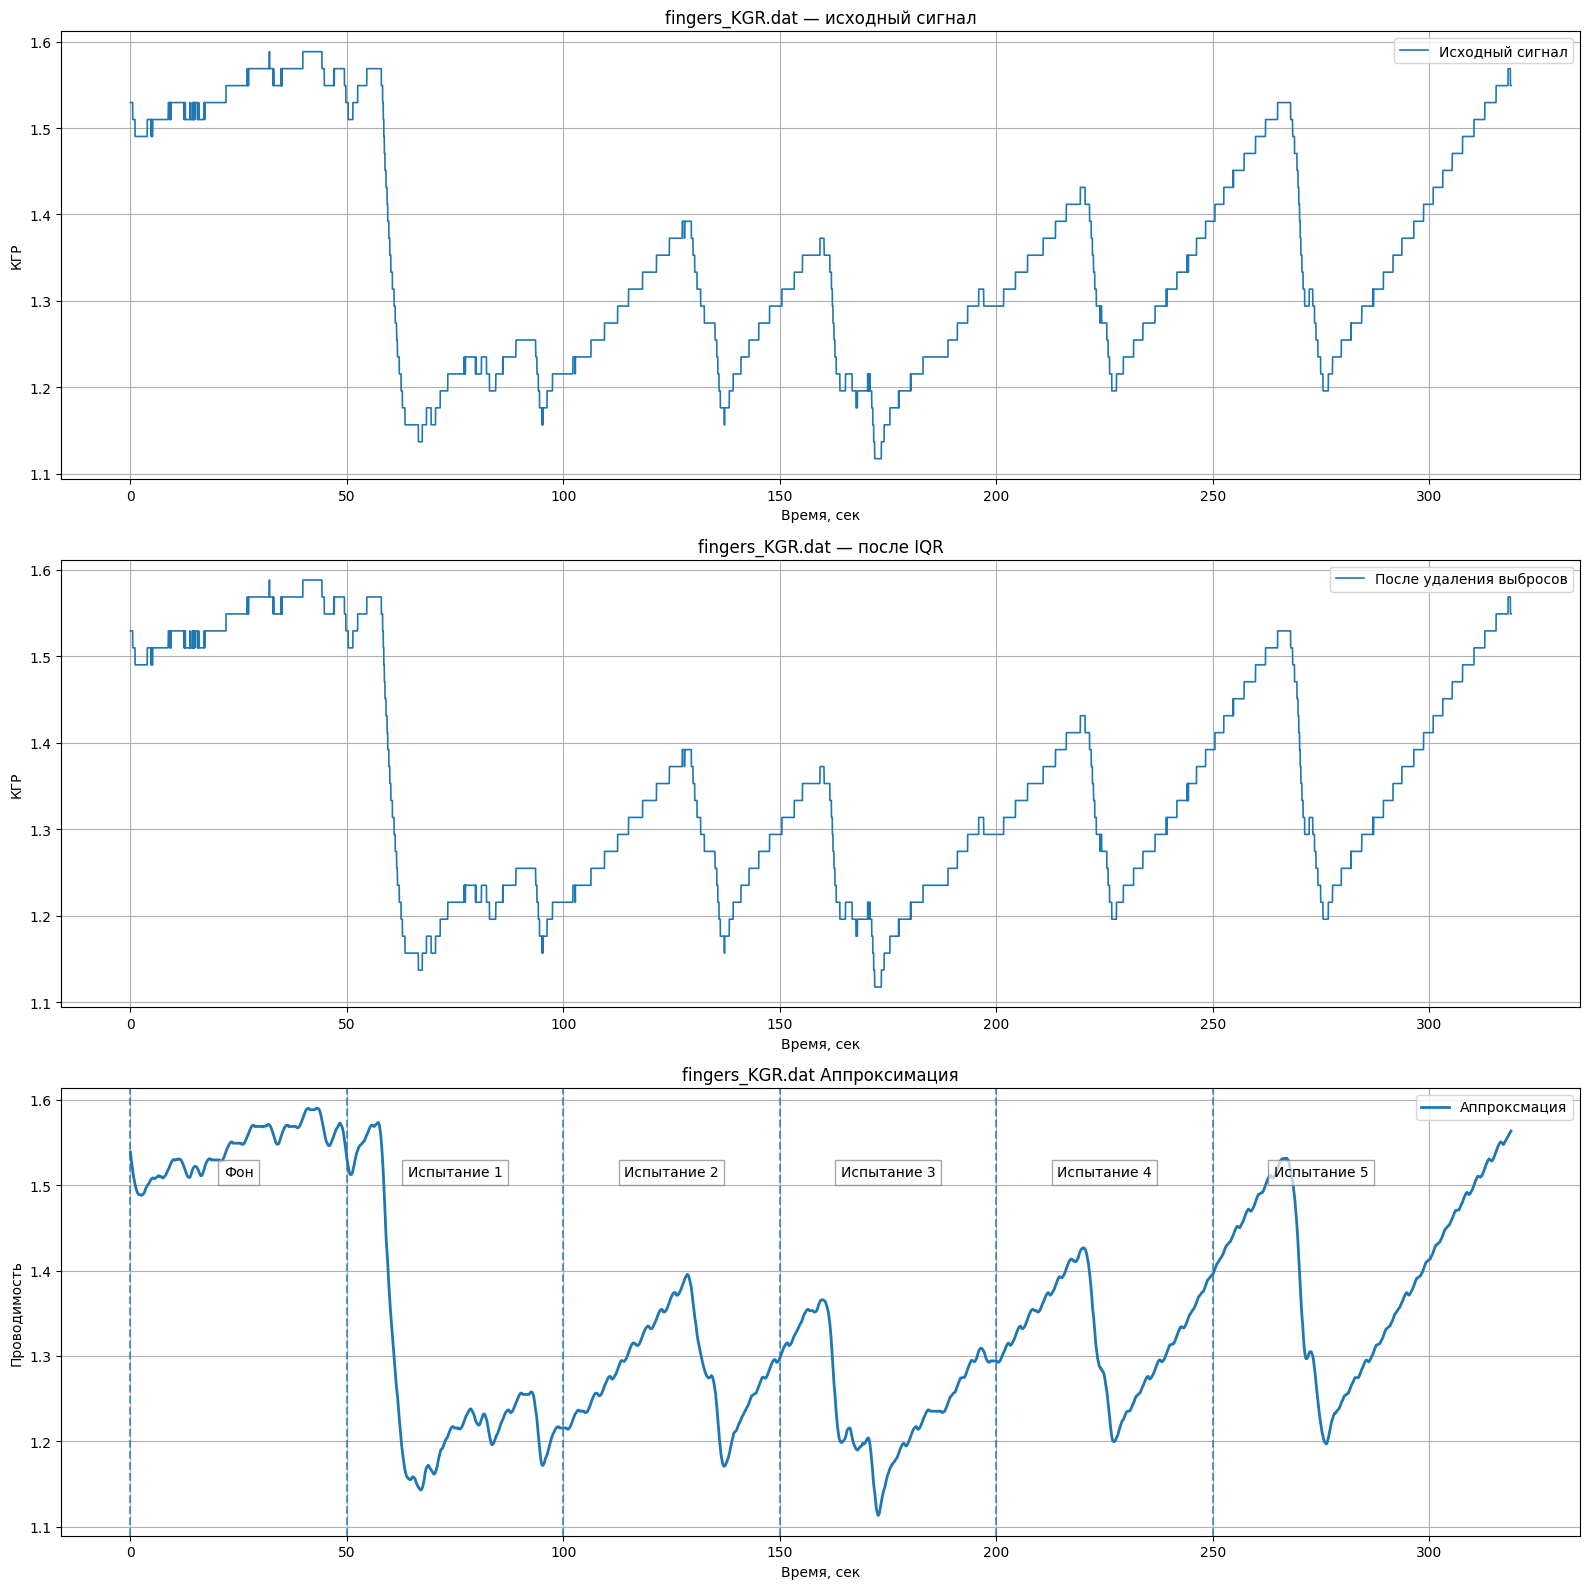


Анализ проводимости 



----------------------------------------------------------------------
Испытание 1
----------------------------------------------------------------------
Минимальное значение: 1.1430
Максимальное значение: 1.5732
Изменение сигнала: 0.4301


----------------------------------------------------------------------
Испытание 2
----------------------------------------------------------------------
Минимальное значение: 1.1708
Максимальное значение: 1.3954
Изменение сигнала: 0.2246


----------------------------------------------------------------------
Испытание 3
----------------------------------------------------------------------
Минимальное значение: 1.1134
Максимальное значение: 1.3658
Изменение сигнала: 0.2524


----------------------------------------------------------------------
Испытание 4
----------------------------------------------------------------------
Минимальное значение: 1.1996
Максимальное значение: 1.4265
Изменение сигнала: 0.2269


-----------

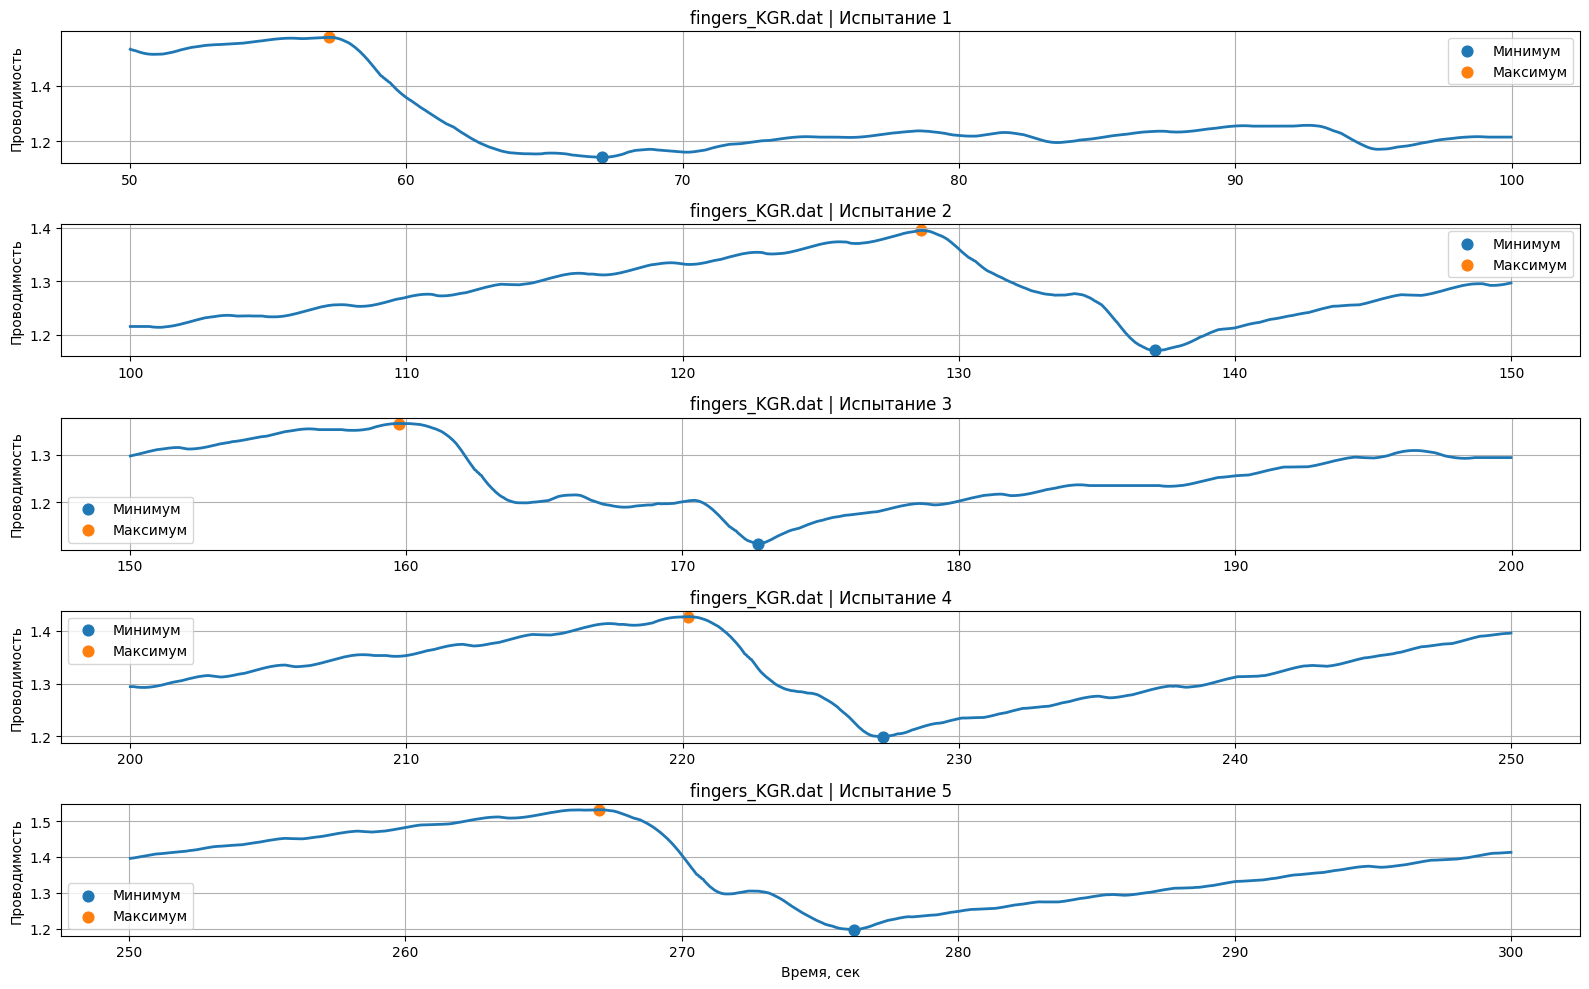


Изменения

      interval  min_signal  max_signal  delta_signal    min_time    max_time
0  Испытание 1    1.143046    1.573188      0.430142   67.070068   57.222412
1  Испытание 2    1.170833    1.395446      0.224614  137.109619  128.642822
2  Испытание 3    1.113361    1.365776      0.252416  172.748291  159.746338
3  Испытание 4    1.199620    1.426524      0.226903  227.266846  220.213135
4  Испытание 5    1.197031    1.531648      0.334617  276.235107  267.018066

Анализ


Наиболее выраженная реакция
наблюдается в интервале:

Испытание 1

Максимальное изменение сигнала:
0.4301


Запуск для файла: scare_KGR.dat 


 Загружаем файл scare_KGR.dat 


 Удаляем выбросы... 
 

Q1: 1.0392
Q3: 1.1176
IQR: 0.0784

Нижняя граница: 0.9216
Верхняя граница: 1.2353

Удалено выбросов: 1334

Сглаживаем сигнал... 
 

 Разделяем на интервалы 

Каждый интервал - отдельное испытание

Фон: 0 - 80 сек
Испытание 1: 80 - 110 сек
Испытание 2: 110 - 150 сек
Испытание 3: 150 - 200 сек
Испытание 4: 200 - 250 

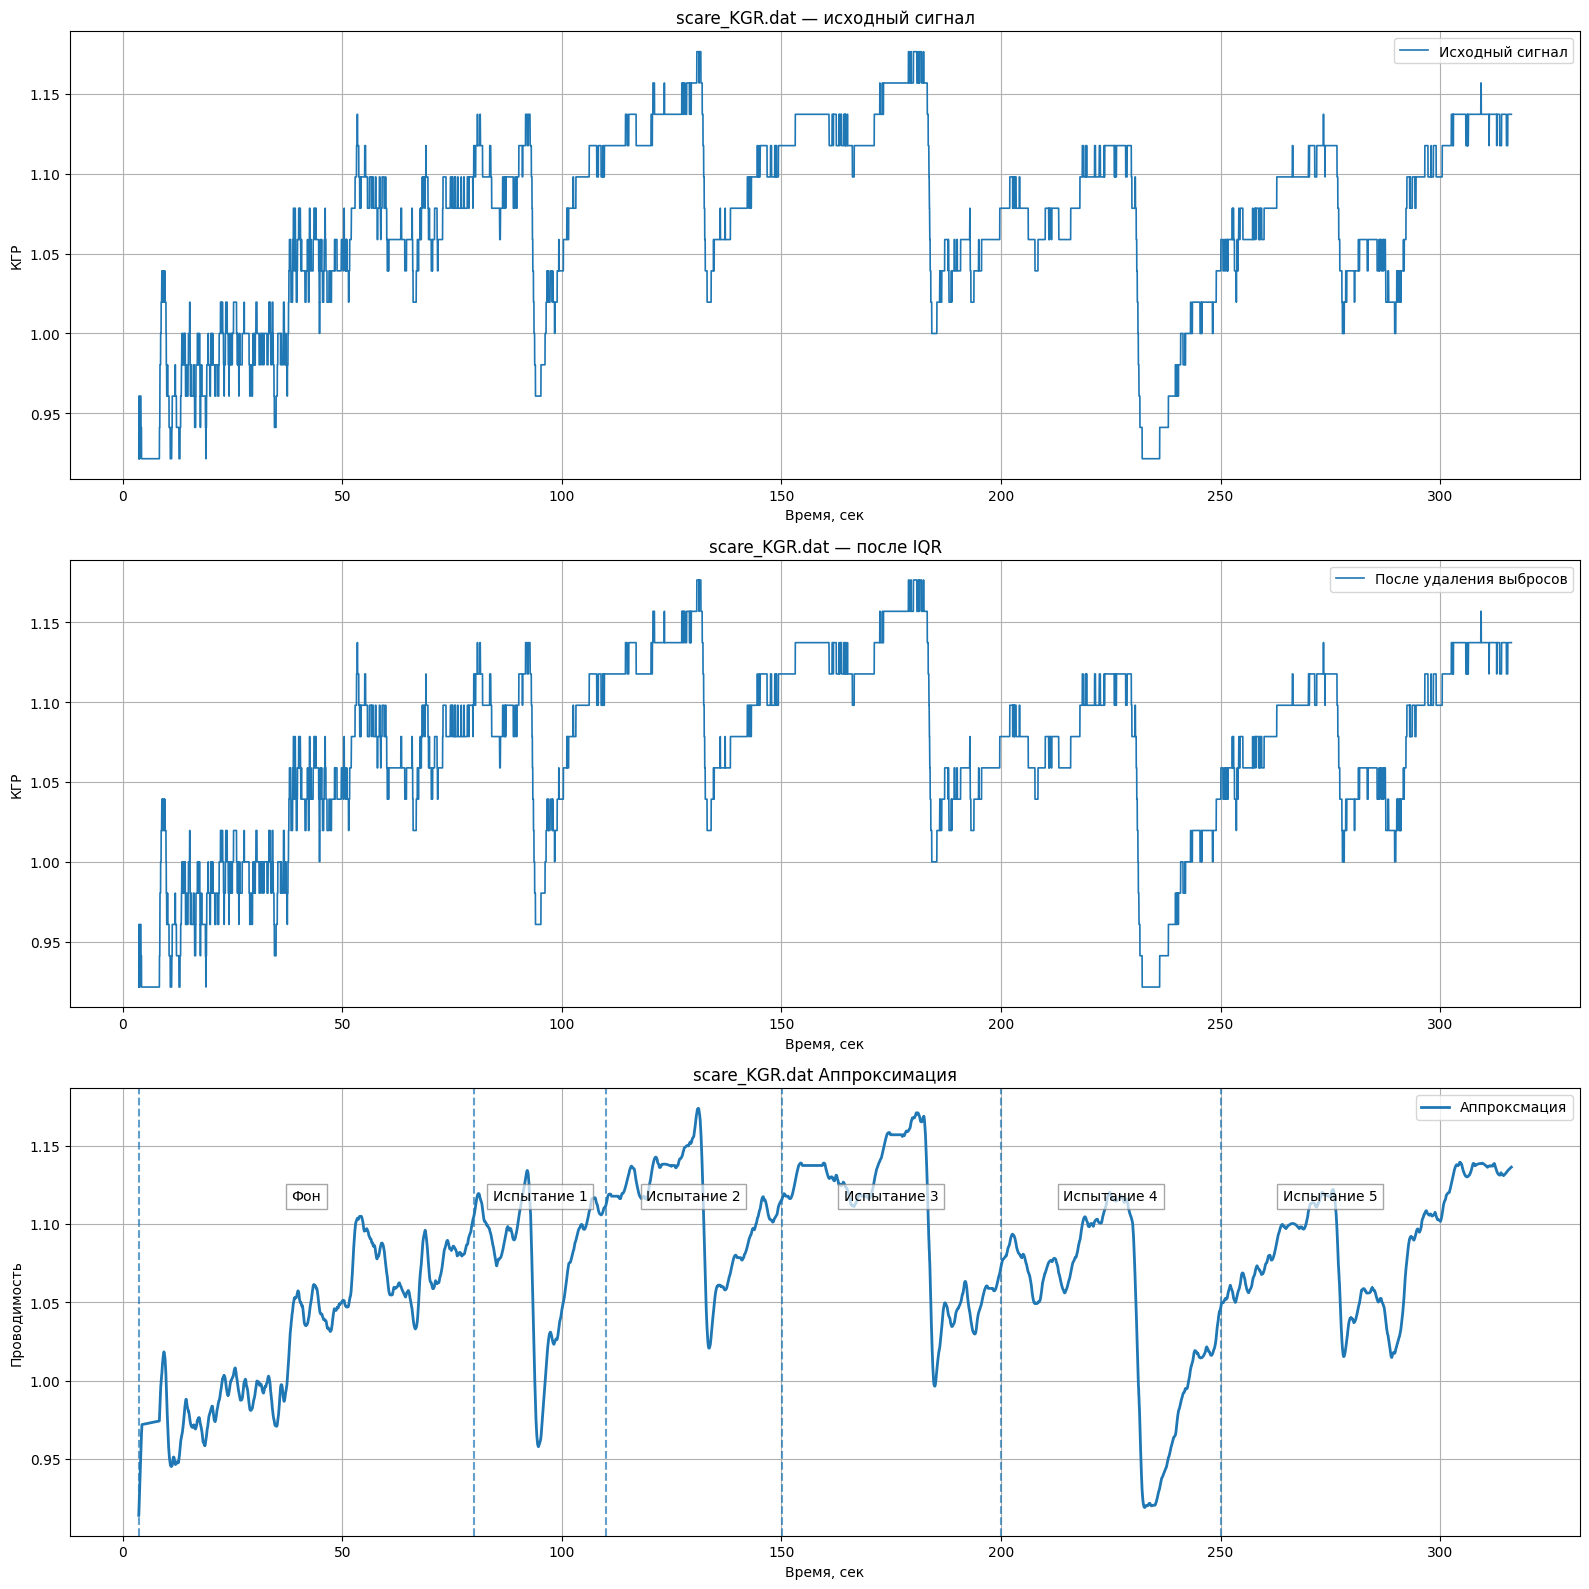


Анализ проводимости 



----------------------------------------------------------------------
Испытание 1
----------------------------------------------------------------------
Минимальное значение: 0.9578
Максимальное значение: 1.1341
Изменение сигнала: 0.1763


----------------------------------------------------------------------
Испытание 2
----------------------------------------------------------------------
Минимальное значение: 1.0206
Максимальное значение: 1.1737
Изменение сигнала: 0.1531


----------------------------------------------------------------------
Испытание 3
----------------------------------------------------------------------
Минимальное значение: 0.9964
Максимальное значение: 1.1709
Изменение сигнала: 0.1745


----------------------------------------------------------------------
Испытание 4
----------------------------------------------------------------------
Минимальное значение: 0.9189
Максимальное значение: 1.1202
Изменение сигнала: 0.2013


-----------

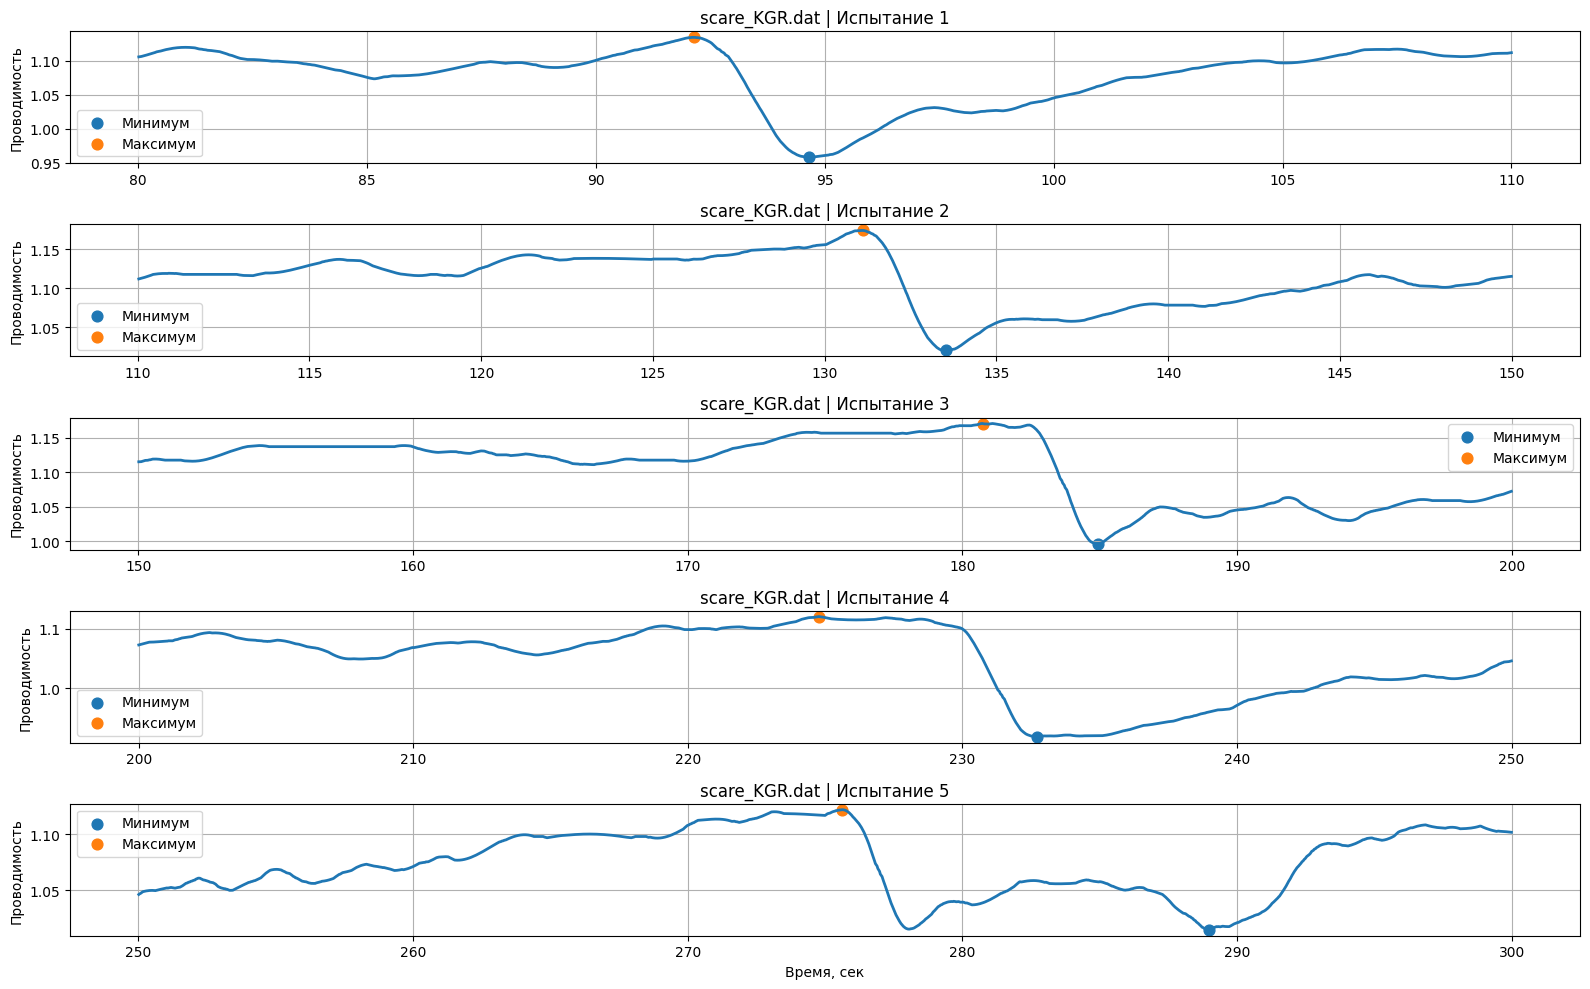


Изменения

      interval  min_signal  max_signal  delta_signal    min_time    max_time
0  Испытание 1    0.957769    1.134060      0.176291   94.659058   92.139771
1  Испытание 2    1.020643    1.173724      0.153081  133.537598  131.108521
2  Испытание 3    0.996352    1.170897      0.174545  184.934814  180.731934
3  Испытание 4    0.918925    1.120203      0.201278  232.702637  224.776245
4  Испытание 5    1.014726    1.122006      0.107280  288.962280  275.632690

Анализ


Наиболее выраженная реакция
наблюдается в интервале:

Испытание 4

Максимальное изменение сигнала:
0.2013



In [ ]:
for filename, config in FILES_CONFIG.items():

    print(f"\nЗапуск для файла: {filename} \n")

    df = load_signal(filename)

    df = remove_outliers_iqr(df)

    df = smooth_signal(df)

    segments = split_intervals(
        df,
        config["intervals"],
        config["labels"]
    )

    plot_signal(
        df,
        segments,
        config["labels"],
        filename
    )

    peaks_results = analyze_peaks(
        segments,
        config["labels"],
        filename
    )

## Выводы

В ходе работы была выполнена обработка и анализ сигналов КГР для нескольких экспериментальных записей. Данные были очищены от выбросов, выполнено сглаживание сигнала с использованием фильтра Савицкого–Голея. Это позволило уменьшить влияние шумов и сделать изменения проводимости более заметными на графиках.

Далее сигнал был разделён на интервалы, соответствующие отдельным испытаниям, и для каждого участка были определены минимальные и максимальные значения проводимости, а также величина изменения сигнала. На основе полученных результатов удалось выявить интервалы с наиболее выраженной реакцией организма.

Таким образом, выполненная обработка данных позволила выделить значимые изменения сигнала, визуализировать динамику проводимости и провести сравнительный анализ реакций в различных экспериментах.

По результатам анализа самая сильная кожно-гальваническая реакция наблюдалась в файле `breathe_KGR.dat`, где изменение сигнала достигло 0.7402. Это говорит о наиболее выраженном изменении проводимости кожи.

Средние значения реакции были получены в файлах `fingers_KGR.dat` и `count_KGR.dat` — около 0.43 и 0.42 соответственно. Наименьшая реакция наблюдалась в `scare_KGR.dat`, где изменения сигнала были минимальными.

Также в файлах `count_KGR.dat` и `scare_KGR.dat` было большое количество выбросов, что указывает на более шумный сигнал по сравнению с остальными экспериментами.